In [57]:
import numpy as np
import matplotlib.pyplot as plt

from imagematerials.rest_of.resource_model import ResourceModel
from imagematerials.rest_of.const import (IAI_TO_IMAGE_CLASSES, 
                                          aluminium_regions, 
                                          path_input_data,
                                          models_output_dict)

In [63]:
# Aluminium
aluminium = ResourceModel(resource_group = 'metals', resource = 'aluminium', 
                       image_mat_available = True, start_year = 1998, end_year = 2024)

all = ['Africa', 
        'Asia (ex China)',
        'Estimated Unreported to IAI', 
        'Gulf Cooperation Council',
        'North America', 
        'Russia & Eastern Europe', 
        'South America',
        'Western & Central Europe']

low_steady = ['Western & Central Europe',
             'North America',
             'Russia & Eastern Europe']

china = ['China (Estimated)']

# will be fitted to global curve
outlier = ['Oceania']
asia = ['Asia (ex China)']

aluminium_regions = {
    'low_steady' : low_steady,
    'all' : all,
    'china' : china,
    'outlier' : outlier
}

aluminium.data_grouped_regions(regions_grouping = aluminium_regions) 

In [59]:
aluminium.sum_IMAGE_drivers_regions(IAI_TO_IMAGE_CLASSES)
aluminium.match_MAT_data_to_regions_year(match_external_regions=True)
aluminium.calculate_historic_other_fraction()

In [60]:
# Deal with negative values in other fraction BEFORE recalculation of other fraction consumption

# 1) Africa: all negative: assumption that apparent MAT is 60% of total consumption (mean until 2017)
# Share of IAMGE MAT data to total consumption
share = (aluminium.image_mat_material_regions.loc[:2017]/aluminium.historic_consumption_data.loc[:2017]*100).mean()
share['Africa']

# starting at 2013 (when negative values start):
aluminium.image_mat_material_regions.loc[:, 'Africa'] = aluminium.historic_consumption_data.loc[:, 'Africa'] * share['Africa'] / 100

# 4) North America
# problem starts at 2015, so take share mean of IMAGE Mat data before that and apply it to 2015-2024
share_na = (aluminium.image_mat_material_regions.loc[:2015]/aluminium.historic_consumption_data.loc[:2015]*100).mean()
aluminium.image_mat_material_regions.loc[:, 'North America'] = aluminium.historic_consumption_data.loc[:, 'North America'] * share_na['North America'] / 100

# 6) South America: assume that share of Mat until 2010 is correct and that apparent consumption needs to be adjusted accordingly 
share_sa = (aluminium.image_mat_material_regions.loc[:2010, 'South America'] / aluminium.historic_consumption_data.loc[:2010, 'South America']).mean()
aluminium.historic_consumption_data.loc[:, 'South America'] = aluminium.image_mat_material_regions.loc[:, 'South America'] / share_sa

# Deal with negative values in other fraction AFTER recalculation of other fraction consumption
# redo calculation of historic other fraction consumption 
aluminium.calculate_historic_other_fraction()

project_on_mat = ['Asia (ex China)', 'Estimated Unreported to IAI']
# 2) rest of Asia: assume that IMAGE Mat is correct and is total per cap consumption 
# so will be projected on total not on diff
aluminium.historic_other_fraction_consumption.loc[:, 'Asia (ex China)'] = aluminium.historic_consumption_data.loc[:, 'Asia (ex China)']

# 3) Estimated Unreported to IAI: assume that IMAGE Mat is correct (these are mostlly IMAGE region 6 regions)
# Most are small island territories, overseas territories or constituent countries mainly linked to France
aluminium.historic_other_fraction_consumption.loc[:, 'Estimated Unreported to IAI'] = aluminium.historic_consumption_data.loc[:, 'Estimated Unreported to IAI']

# 5) Gulf Cooperation Council: remove negative values to nan, no problems in more recent years
aluminium.historic_other_fraction_consumption.loc[aluminium.historic_other_fraction_consumption.loc[:, 'Gulf Cooperation Council'] < 0, 'Gulf Cooperation Council'] = np.nan

# Finally check the whole dataframe for single negative values and make them NaN
aluminium.historic_other_fraction_consumption[aluminium.historic_other_fraction_consumption < 0] = np.nan

In [61]:
aluminium.historic_other_fraction_consumption

,Africa,Asia (ex China),China (Estimated),Estimated Unreported to IAI,Gulf Cooperation Council,North America,Oceania,Russia & Eastern Europe,South America,Western & Central Europe
1988,NaN,6.264801e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1989,NaN,5.223609e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990,NaN,3.435971e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1991,NaN,6.191659e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1992,NaN,7.972590e+05,NaN,4.689961e+06,NaN,NaN,NaN,NaN,NaN,NaN
1993,NaN,5.913259e+05,NaN,4.738436e+06,NaN,NaN,NaN,NaN,NaN,NaN
1994,NaN,6.325063e+05,NaN,3.989005e+06,NaN,NaN,NaN,NaN,NaN,NaN
1995,NaN,2.960242e+05,NaN,2.362097e+06,NaN,NaN,NaN,NaN,NaN,NaN
1996,NaN,3.865528e+05,NaN,2.216125e+06,NaN,NaN,NaN,NaN,NaN,NaN
1997,NaN,4.942532e+05,NaN,1.749081e+06,NaN,NaN,NaN,NaN,NaN,NaN


In [62]:
# Fit models
aluminium.calculate_regressors(aluminium.historic_other_fraction_consumption)
aluminium.fit_models(best_rmse_models= {
    'low_steady' : 'gompertz model',
                     'all' : 'gompertz model',
                     'china' : 'gompertz model',
    'outlier' : 'gompertz model'})
# Projections


aluminium.project_on_total(list(IAI_TO_IMAGE_CLASSES.keys()))

low_steady
limited growth model Optimal parameters not found: Number of calls to function has reached maxfev = 800.
all
china
limited growth model Optimal parameters not found: Number of calls to function has reached maxfev = 800.
outlier
limited growth model Optimal parameters not found: Number of calls to function has reached maxfev = 800.


C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:127: OptimizeWarning: Covariance of the parameters could not be estimated
  self._coefs, _ = curve_fit(self._model_func, self._X, self._y) #bounds=(-100, 100.000), p0=[1, 1000, 1000], method='lm'
C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:127: OptimizeWarning: Covariance of the parameters could not be estimated
  self._coefs, _ = curve_fit(self._model_func, self._X, self._y) #bounds=(-100, 100.000), p0=[1, 1000, 1000], method='lm'
C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:127: OptimizeWarning: Covariance of the parameters could not be estimated
  self._coefs, _ = curve_fit(self._model_func, self._X, self._y) #bounds=(-100, 100.000), p0=[1, 1000, 1000], method='lm'
C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:281: RuntimeWarning: overflow encountere

ValueError: Length mismatch: Expected axis has 9 elements, new values have 10 elements

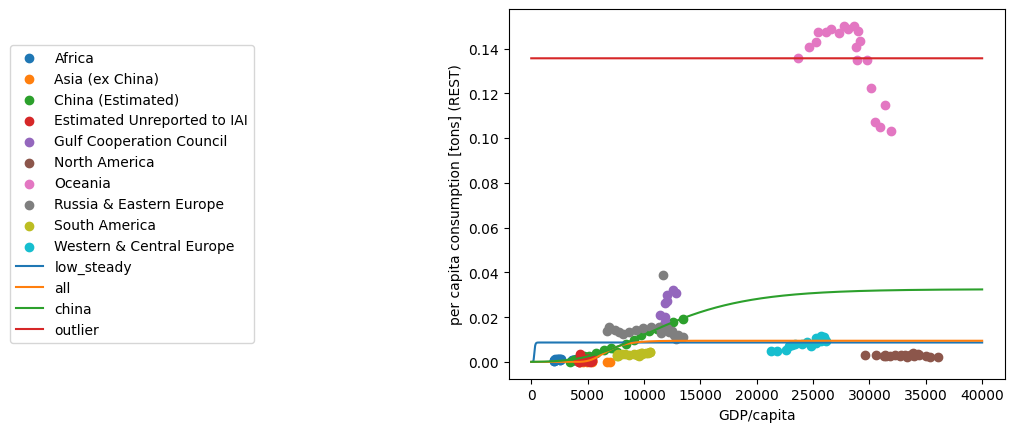

In [ ]:
# Plot regression with GDP/cap on x axis and cons/cap on y axis only for years that were fitted

colors = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',
    '#aec7e8', '#ffbb78', '#98df8a', '#ff9896', '#c5b0d5',
    '#c49c94', '#f7b6d2', '#c7c7c7', '#dbdb8d', '#9edae5',
    '#393b79', '#637939', '#8c6d31', '#843c39', '#7b4173',
    '#5254a3'
]

color_dict_fits = {
    'low_steady' : '#1f77b4',  # blue
    'all' : '#ff7f0e',  # orange
    'china' : '#2ca02c',  # green
    'outlier' : '#d62728'  # red

}


# Create the mapping dictionary
color_dict = {f"class_ {i+1}": colors[i] for i in range(26)}

fig, ax = plt.subplots()             # Create a figure containing a single Axes.


for region in aluminium.cons_capita.columns:
    ax.scatter(aluminium.gdp_pc[region], 
               aluminium.cons_capita[region], 
               label = region,
               color = color_dict.get(region))
    
    
for grouping in aluminium_regions.keys():
    model = aluminium.model_groups[grouping][models_output_dict[aluminium.best_rmse_models[grouping]]]
    ax.plot(model.predict(np.arange(1, 40001).reshape(-1, 1)),
            label = grouping,
            color = color_dict_fits[grouping])

ax.set_ylabel("per capita consumption [tons] (REST)")
ax.set_xlabel("GDP/capita")



ax.legend(loc = 'right', bbox_to_anchor=(-0.5, 0.5))

In [ ]:
aluminium.image_mat_material_regions_total

,Africa,Asia (ex China),China (Estimated),Estimated Unreported to IAI,Gulf Cooperation Council,North America,Oceania,Russia & Eastern Europe,South America,Western & Central Europe
1721,2.355261e+00,1.437222e+01,1.604662e+01,1.538545e+00,6.366750e-01,8.084800e-01,0.020293,3.892525e+00,6.241905e-01,7.877138e+00
1722,7.758668e+00,4.735758e+01,5.287500e+01,5.068701e+00,2.098107e+00,2.624078e+00,0.068029,1.283332e+01,2.056711e+00,2.609544e+01
1723,1.421116e+01,8.676423e+01,9.687784e+01,9.284825e+00,3.844296e+00,4.740969e+00,0.126573,2.352368e+01,3.768010e+00,4.804141e+01
1724,2.172244e+01,1.326525e+02,1.481361e+02,1.419326e+01,5.877871e+00,7.162379e+00,0.196005,3.597926e+01,5.760623e+00,7.374521e+01
1725,3.029979e+01,1.850685e+02,2.067238e+02,1.979874e+01,8.200794e+00,9.890586e+00,0.276381,5.021144e+01,8.036409e+00,1.032276e+02
...,...,...,...,...,...,...,...,...,...,...
2056,1.017919e+07,2.349491e+07,1.256663e+07,7.603203e+06,2.693192e+06,9.331655e+06,778329.385824,3.869136e+06,5.674939e+06,9.868058e+06
2057,1.058906e+07,2.382683e+07,1.250241e+07,7.908770e+06,2.752786e+06,9.401576e+06,795543.956459,3.905878e+06,5.724259e+06,9.829195e+06
2058,1.101794e+07,2.421156e+07,1.249236e+07,8.226122e+06,2.816906e+06,9.523825e+06,807858.787373,3.891176e+06,5.797555e+06,9.872493e+06
2059,1.148657e+07,2.442873e+07,1.238699e+07,8.569053e+06,2.871404e+06,9.617778e+06,826238.051295,3.868987e+06,5.852162e+06,9.842658e+06


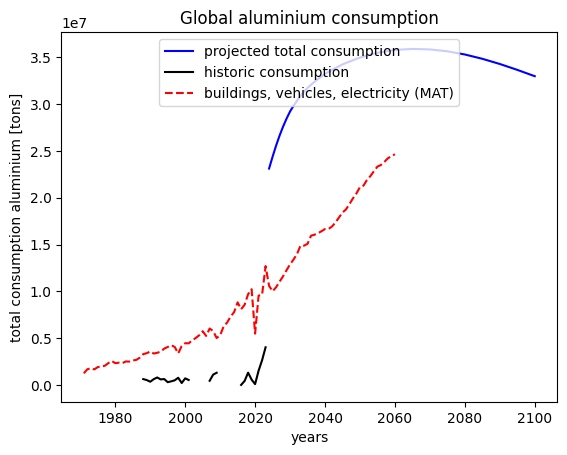

In [ ]:
fig, ax = plt.subplots()             # Create a figure containing a single Axes.

region = 'Asia (ex China)'

if region in project_on_mat:
    ax.plot(aluminium.projection_per_region_total[region].loc[2024:, ],
            linestyle = '-', color = 'blue', label = 'projected total consumption')
else:
      ax.plot(aluminium.projection_per_region_total[region].loc[2024:, ] + aluminium.image_mat_material_regions_total[region].loc[2024:, ],
        linestyle = '--', color = 'blue', label = 'projected total consumption')

ax.plot(aluminium.historic_consumption_data[region],
        linestyle = '-', color = 'black', label = 'historic consumption')  

ax.plot(aluminium.image_mat_material_regions_total[region].loc[1971:],
        linestyle = '--', color = 'red', label = 'buildings, vehicles, electricity (MAT)')

ax.set_ylabel("total consumption aluminium [tons]")
ax.set_xlabel("years") 
ax.title.set_text("Global aluminium consumption")
ax.legend(loc = 'upper center')